In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load all the data

In [3]:
data_train = pd.read_csv("../data/raw/train.csv")
data_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
data_holidays = pd.read_csv("../data/raw/holidays_events.csv")
data_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [5]:
data_oil = pd.read_csv("../data/raw/oil.csv")
data_oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
data_stores = pd.read_csv("../data/raw/stores.csv")
data_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [7]:
data_transactions = pd.read_csv("../data/raw/transactions.csv")
data_transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


## Observe the data
Find all the possible relations in data         
Do holidays have a huge effect?     
Do all the products behave the same? How about stores?    

In [10]:
print("Shape:", data_train.shape)

print("First date:", data_train["date"].min())
print("Last date:", data_train["date"].max())

print("Number of stores:", data_train["store_nbr"].nunique())
print("Number of product families:", data_train["family"].nunique())

Shape: (3000888, 6)
First date: 2013-01-01
Last date: 2017-08-15
Number of stores: 54
Number of product families: 33


### Hypothesis : As we move forward the general sales rises

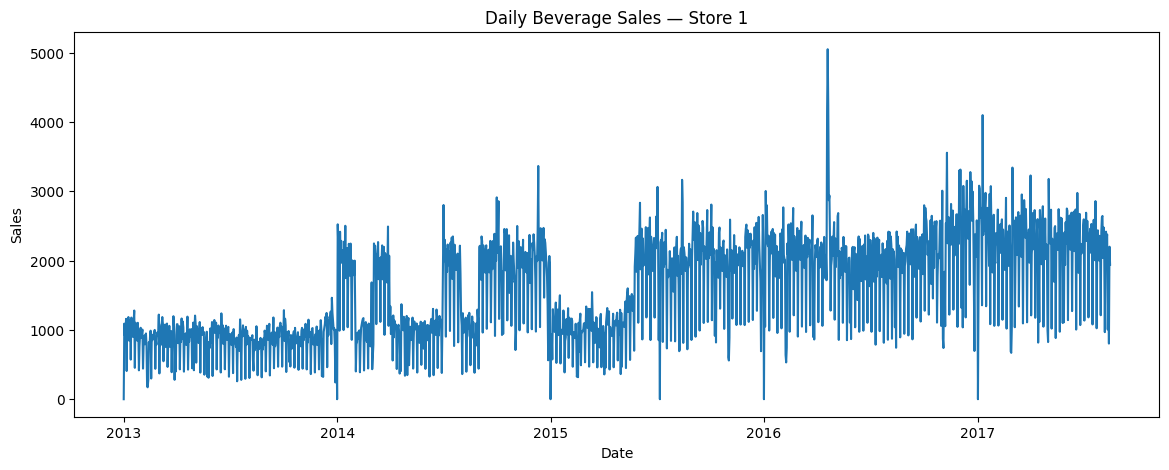

In [11]:
sample = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

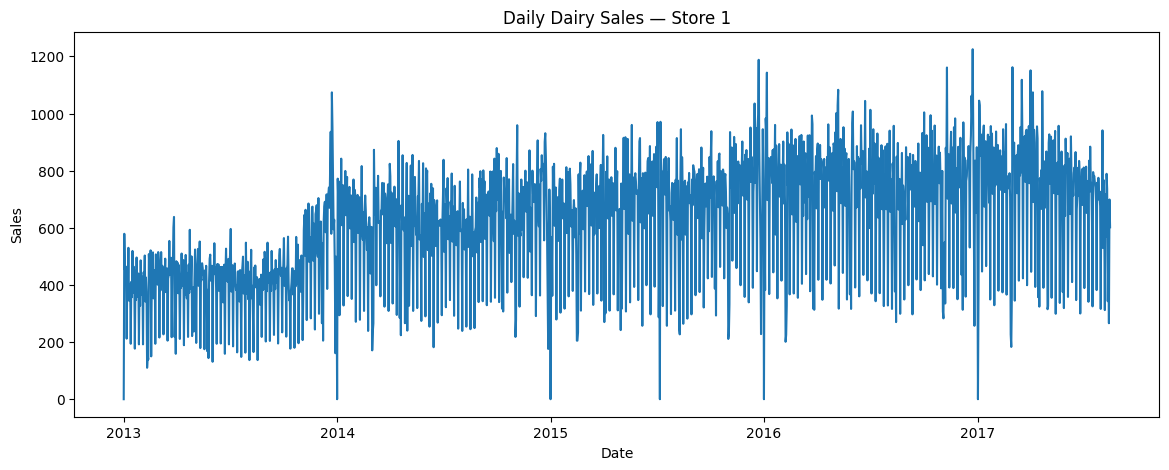

In [12]:
sample2 = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "DAIRY")
].copy()

sample2["date"] = pd.to_datetime(sample2["date"])
sample2 = sample2.sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(sample2["date"], sample2["sales"])

plt.title("Daily Dairy Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

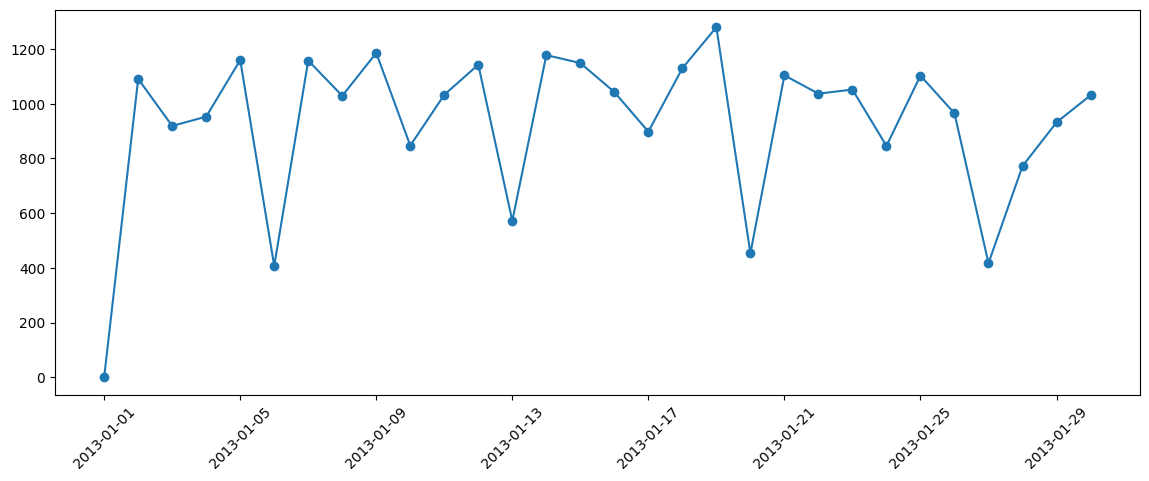

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample["date"].head(30),
    sample["sales"].head(30),
    marker="o"
)

plt.xticks(rotation=45)
plt.show()

### Hypothesis: There's a weekly pattern. We have a great loss in sales on Sundays

In [19]:
sample['day'] = sample['date'].dt.dayofweek
grouped_sample = sample.groupby('day', as_index=False).mean(numeric_only=True)
grouped_sample[['day', 'sales']]

,day,sales
0,0,1700.294606
1,1,1651.483471
2,2,1847.425000
3,3,1576.458333
4,4,1732.033333
5,5,1820.576763
6,6,784.000000


In [24]:
print(sample.shape)
print(sample["date"].min(), sample["date"].max())
print(sample['date'].dt.dayofweek.value_counts())

(1684, 7)
2013-01-01 00:00:00 2017-08-15 00:00:00
date
1    242
0    241
5    241
3    240
2    240
4    240
6    240
Name: count, dtype: int64


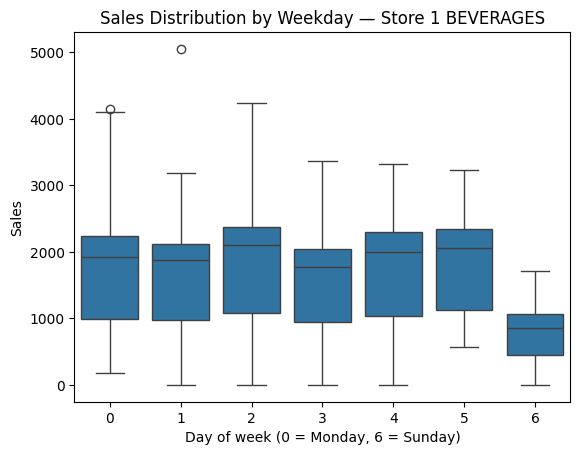

In [25]:
sns.boxplot(data=sample, x="day", y="sales")

plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
plt.ylabel("Sales")
plt.title("Sales Distribution by Weekday — Store 1 BEVERAGES")

plt.show()

### Hypothesis : Sundays have a low sale

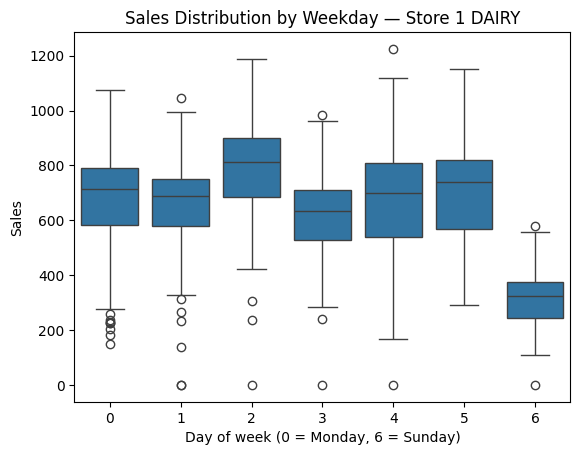

In [27]:
sample2 = data_train[
    (data_train["store_nbr"] == 1) &
    (data_train["family"] == "DAIRY")
].copy()

sample2["date"] = pd.to_datetime(sample2["date"])
sample2["day"] = sample2["date"].dt.dayofweek

sns.boxplot(data=sample2, x="day", y="sales")

plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
plt.ylabel("Sales")
plt.title("Sales Distribution by Weekday — Store 1 DAIRY")

plt.show()

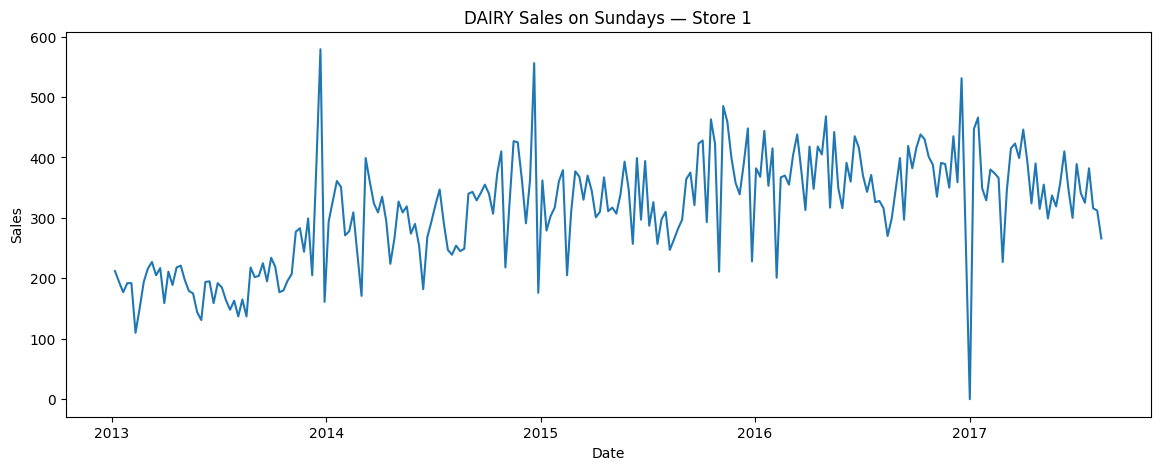

In [29]:
sunday = sample2[sample2["day"] == 6]

plt.figure(figsize=(14, 5))
plt.plot(sunday["date"], sunday["sales"])
plt.title("DAIRY Sales on Sundays — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

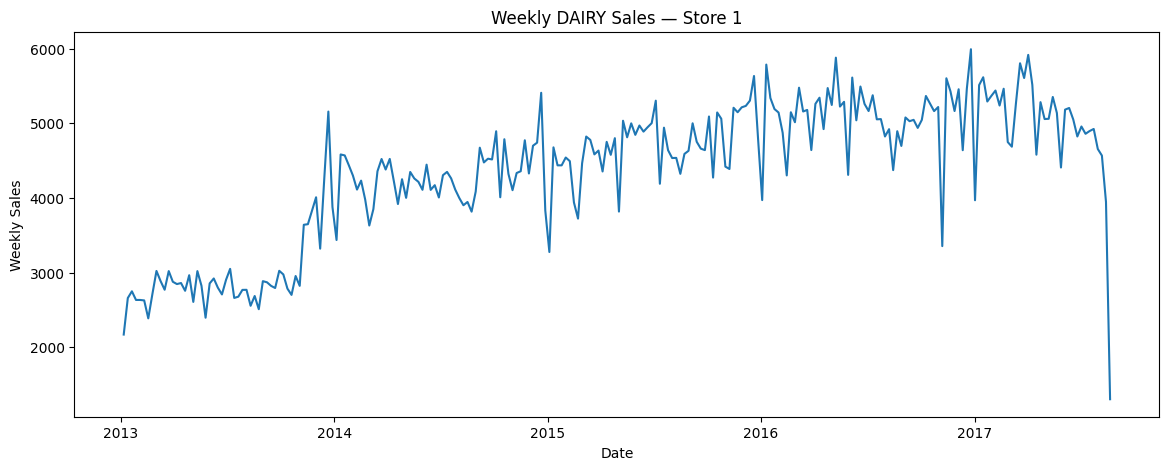

In [30]:
sample2 = sample2.sort_values("date")

weekly = (
    sample2
    .set_index("date")["sales"]
    .resample("W")
    .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(weekly)
plt.title("Weekly DAIRY Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [31]:
weekly.sort_values().head(10)

date
2017-08-20    1301.0
2013-01-06    2168.0
2013-02-17    2385.0
2013-05-26    2394.0
2013-08-25    2508.0
2013-08-11    2554.0
2013-05-05    2606.0
2013-02-10    2626.0
2013-01-27    2632.0
2013-02-03    2632.0
Name: sales, dtype: float64

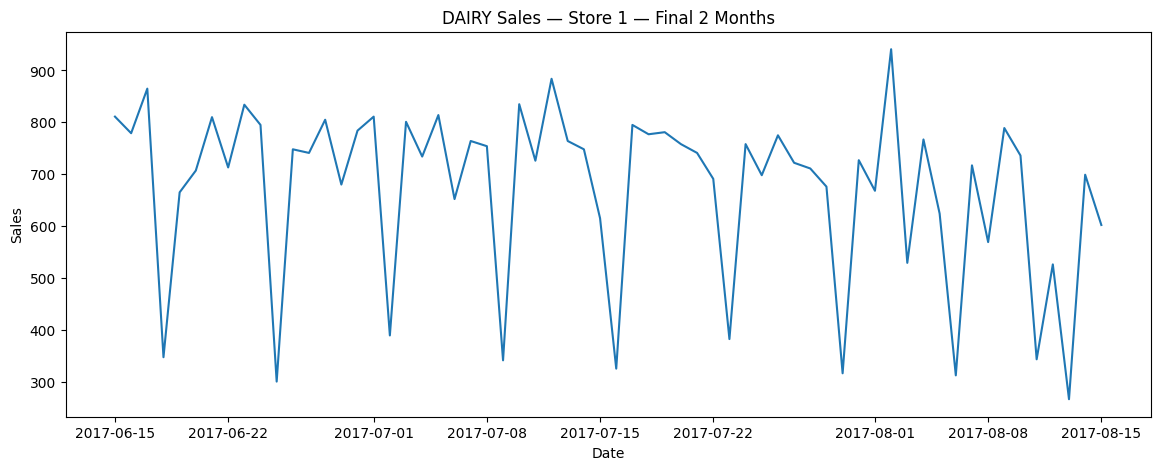

In [33]:
recent = sample2[sample2["date"] >= "2017-06-15"]

plt.figure(figsize=(14, 5))
plt.plot(recent["date"], recent["sales"])
plt.title("DAIRY Sales — Store 1 — Final 2 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Work on hypothesis

We'll work towards confirming the two patterns found here:
1. we have a general rise as time goes by
2. we have a low sales day on Saturdays

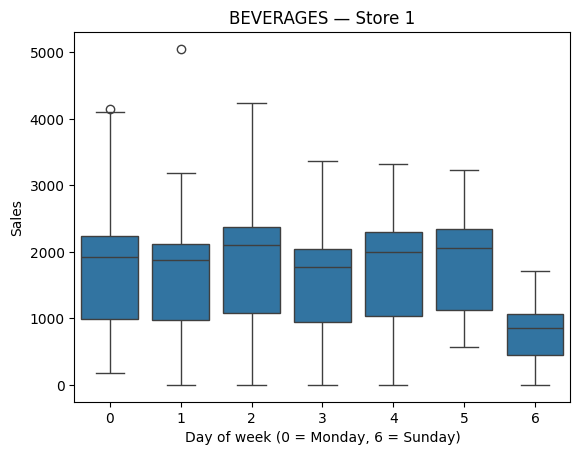

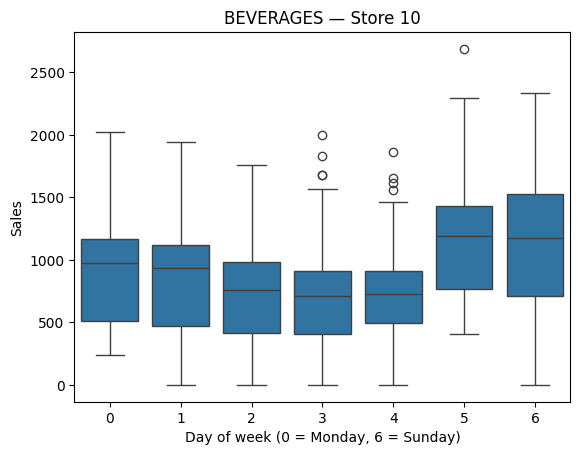

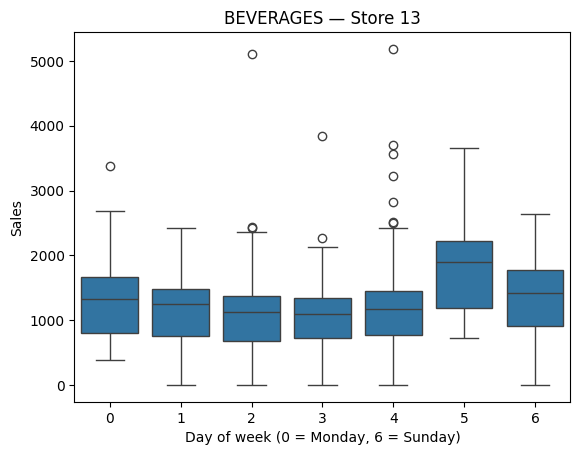

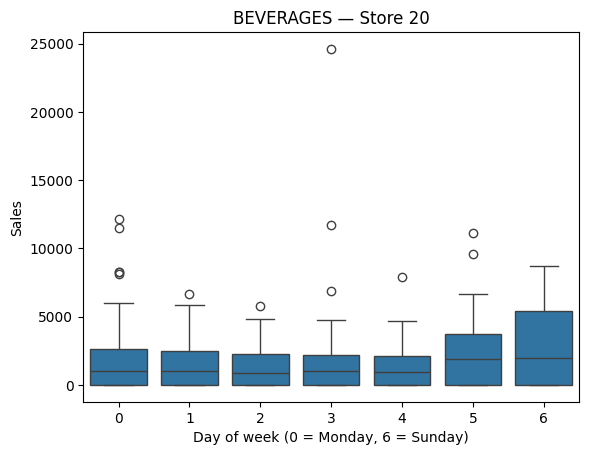

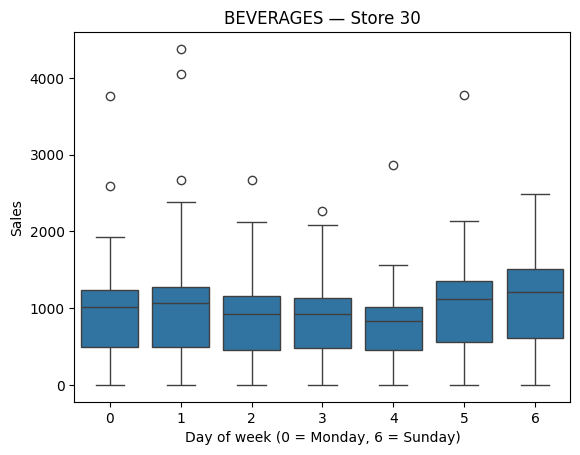

In [39]:
stores_to_check = [1, 10, 13, 20, 30]

for store in stores_to_check:

    temp = data_train[
        (data_train["store_nbr"] == store) &
        (data_train["family"] == "BEVERAGES")
    ].copy()

    temp["date"] = pd.to_datetime(temp["date"])
    temp["day"] = temp["date"].dt.dayofweek

    sns.boxplot(data=temp, x="day", y="sales")

    plt.title(f"BEVERAGES — Store {store}")
    plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
    plt.ylabel("Sales")
    plt.show()

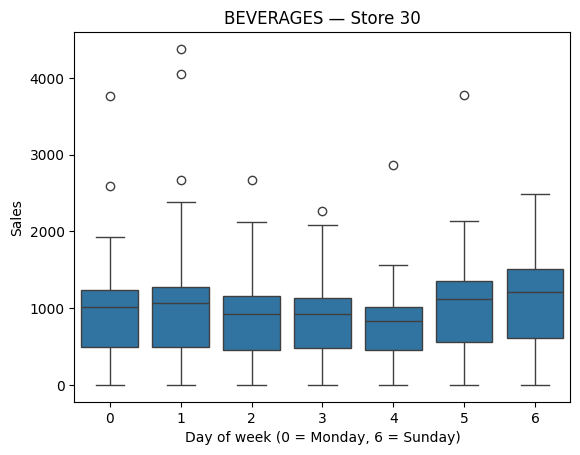

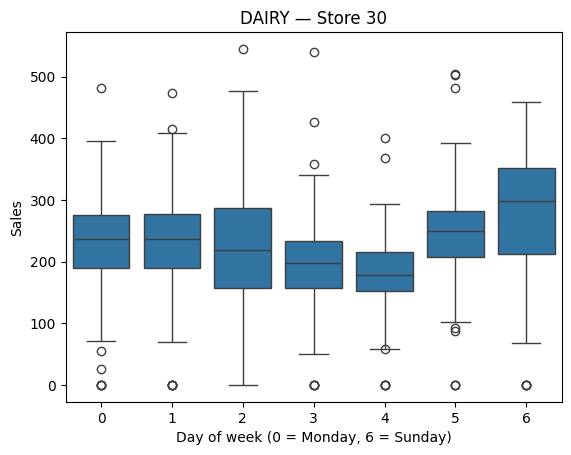

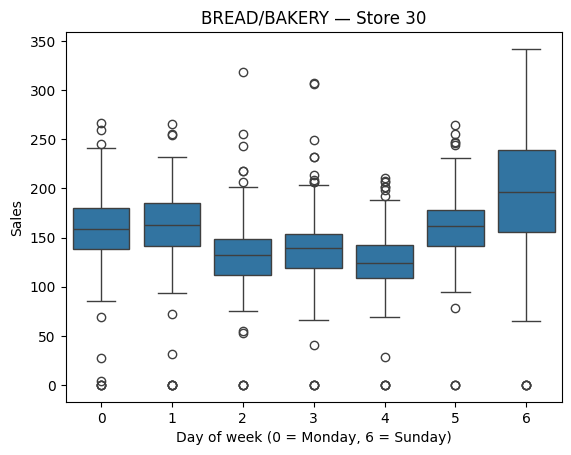

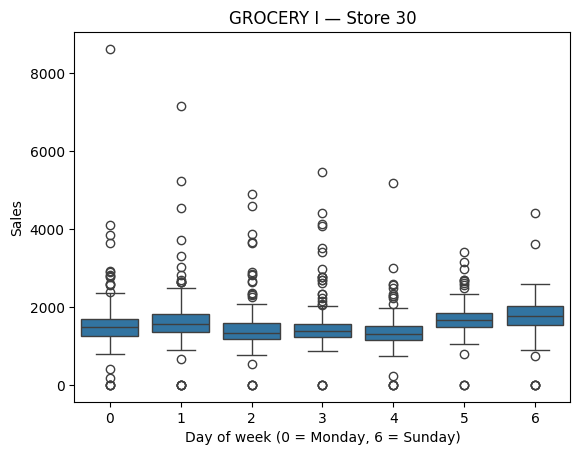

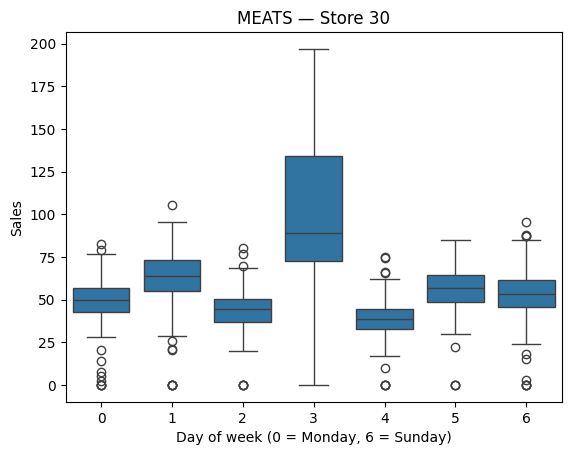

In [36]:
families = ["BEVERAGES", "DAIRY", "BREAD/BAKERY", "GROCERY I", "MEATS"]

for family in families:

    temp = data_train[
        (data_train["store_nbr"] == 30) &
        (data_train["family"] == family)
    ].copy()

    temp["date"] = pd.to_datetime(temp["date"])
    temp["day"] = temp["date"].dt.dayofweek

    sns.boxplot(data=temp, x="day", y="sales")

    plt.title(f"{family} — Store 30")
    plt.xlabel("Day of week (0 = Monday, 6 = Sunday)")
    plt.ylabel("Sales")
    plt.show()

Do we have a general rise in sales?

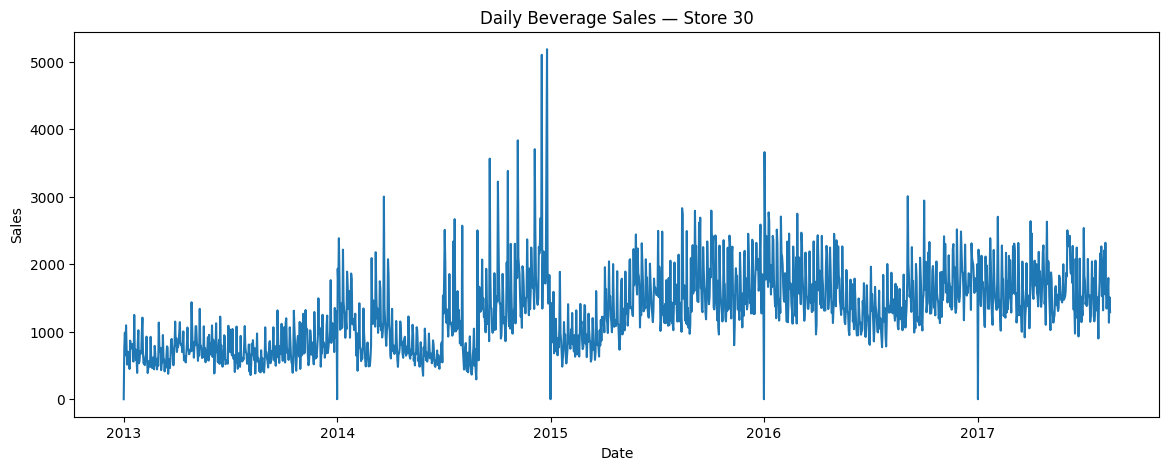

In [41]:
sample = data_train[
    (data_train["store_nbr"] == 13) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 30")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

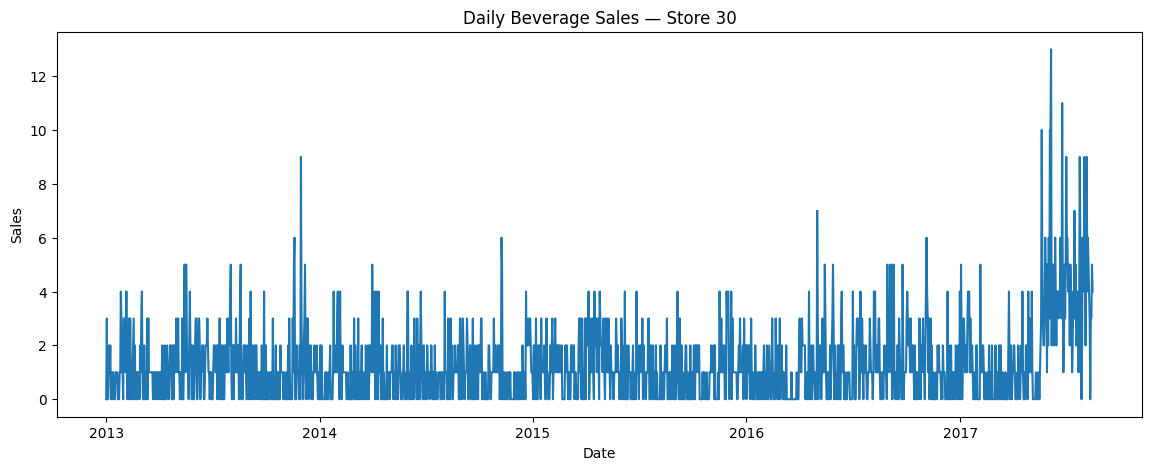

In [42]:
sample = data_train[
    (data_train["store_nbr"] == 13) &
    (data_train["family"] == "BEAUTY")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 30")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

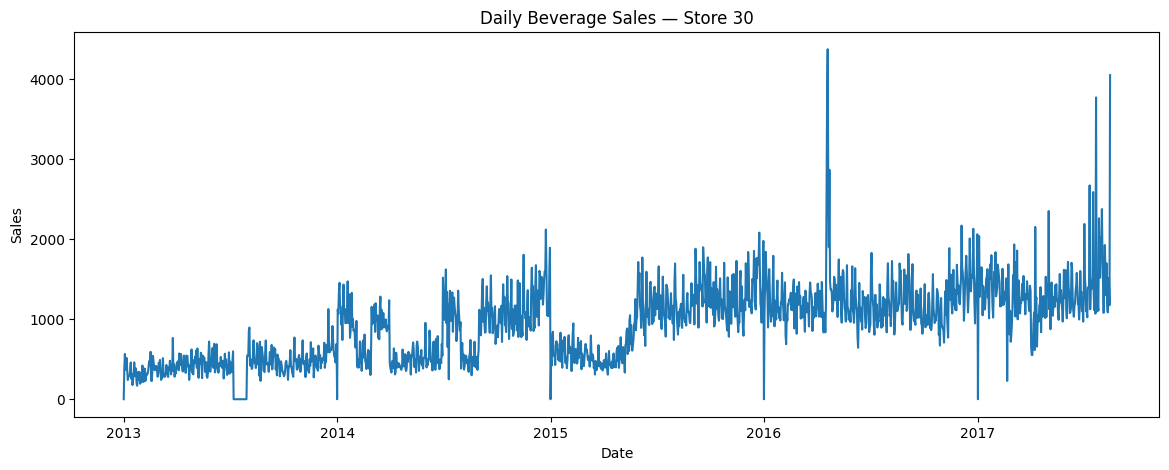

In [40]:
sample = data_train[
    (data_train["store_nbr"] == 30) &
    (data_train["family"] == "BEVERAGES")
].copy()

sample["date"] = pd.to_datetime(sample["date"])

sample = sample.sort_values("date")

plt.figure(figsize=(14, 5))

plt.plot(sample["date"], sample["sales"])

plt.title("Daily Beverage Sales — Store 30")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

Do we have a weekly trend in different families in different stores? 

In [38]:
temp = data_train[data_train["store_nbr"] == 30].copy()

temp["date"] = pd.to_datetime(temp["date"])
temp["day"] = temp["date"].dt.dayofweek

weekday_family = (
    temp.groupby(["family", "day"])["sales"]
    .mean()
    .unstack()
)

weekday_family

day,0,1,2,3,4,5,6
family,,,,,,,
AUTOMOTIVE,2.929461,3.090909,2.604167,3.050000,2.850000,3.668050,3.383333
BABY CARE,0.099585,0.074380,0.058333,0.058333,0.045833,0.078838,0.050000
BEAUTY,0.614108,0.582645,0.508333,0.483333,0.487500,0.726141,0.779167
BEVERAGES,937.373444,983.004132,856.662500,855.229167,771.975000,1010.336100,1104.037500
BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BREAD/BAKERY,157.165975,159.429752,131.366667,137.183333,124.737500,159.219917,195.283333
CELEBRATION,1.970954,2.000000,2.500000,2.525000,2.666667,3.041494,2.300000
CLEANING,491.178423,494.648760,421.254167,442.029167,458.654167,545.145228,508.845833
DAIRY,223.456432,224.892562,220.533333,192.875000,178.791667,239.858921,277.795833
